In [2]:
import pandas as pd
import numpy as np

files = [
    '500m_ib_mol_enamine_block_with_true_blocks.parquet', '500m_ib_mol_enamine_block.parquet',
    '500m_ib_mol_zinc22_block_with_true_blocks.parquet', '500m_ib_mol_zinc22_block.parquet',
    '500m_zinc22_mol_enamine_block_with_true_blocks.parquet', '500m_zinc22_mol_enamine_block.parquet',
    '500m_zinc22_mol_zinc22_block_with_true_blocks.parquet', '500m_zinc22_mol_zinc22_block.parquet',
]

df = []
for f in files:
    tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/'+f)
    tmp['file'] = f
    df.append(tmp)

df = pd.concat(df)

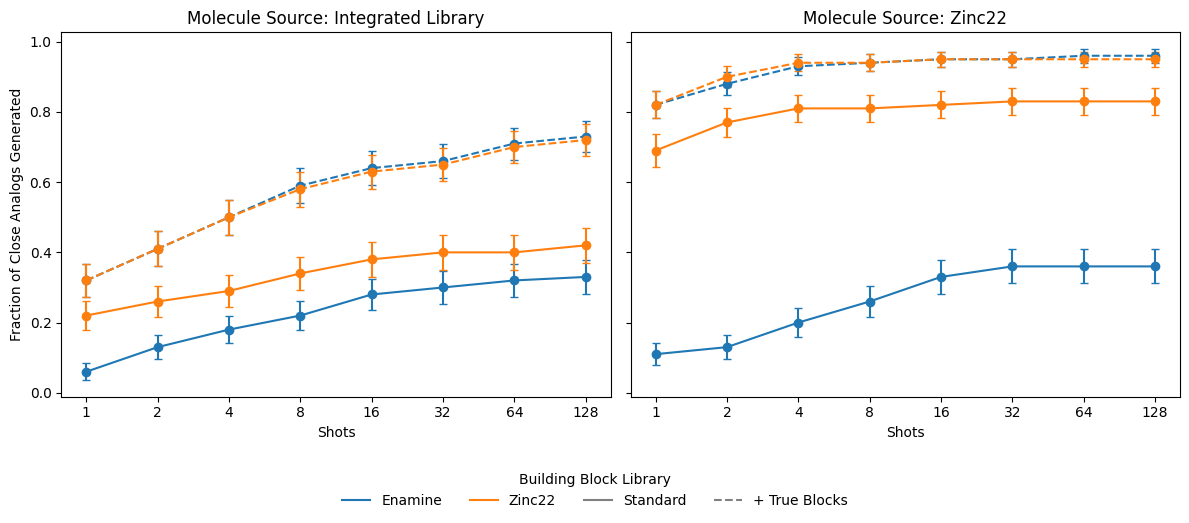

In [3]:
import matplotlib.pyplot as plt

# Parse file names into nice columns
def parse_file(f):
    mol_source = 'Integrated Library' if '_ib_mol_' in f else 'Zinc22'
    lib_source = 'Enamine' if '_enamine_' in f else 'Zinc22'
    has_truth = 'with_true_blocks' in f
    return mol_source, lib_source, has_truth

# Build results
results = []
for thresh in [1, 2, 4, 8, 16, 32, 64, 128]:
    new_df = df[df['shot_number'] < thresh]
    # Get per-molecule success (boolean)
    mol_success = (new_df.groupby(['file', 'source_smiles'])['tanimoto_sim'].max() > 0.85)
    # Compute mean and std error per file
    stats = mol_success.groupby('file').agg(['mean', 'std', 'count'])
    for f, row in stats.iterrows():
        mol_source, lib_source, has_truth = parse_file(f)
        se = row['std'] / np.sqrt(row['count'])
        results.append({'shots': thresh, 'perf': row['mean'], 'se': se, 'mol_source': mol_source, 'lib_source': lib_source, 'has_truth': has_truth})

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {'Enamine': 'tab:blue', 'Zinc22': 'tab:orange'}
linestyles = {False: '-', True: '--'}

for ax, mol_src in zip(axes, ['Integrated Library', 'Zinc22']):
    sub = results_df[results_df['mol_source'] == mol_src]
    for lib in ['Enamine', 'Zinc22']:
        for has_truth in [False, True]:
            mask = (sub['lib_source'] == lib) & (sub['has_truth'] == has_truth)
            data = sub[mask].sort_values('shots')
            ax.errorbar(data['shots'], data['perf'], yerr=data['se'], color=colors[lib], linestyle=linestyles[has_truth], marker='o', capsize=3)
    ax.set_title(f'Molecule Source: {mol_src}')
    ax.set_xlabel('Shots')
    ax.set_xscale('log', base=2)
    ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

axes[0].set_ylabel('Fraction of Close Analogs Generated')

# Single legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', label='Enamine'),
    Line2D([0], [0], color='tab:orange', label='Zinc22'),
    Line2D([0], [0], color='gray', linestyle='-', label='Standard'),
    Line2D([0], [0], color='gray', linestyle='--', label='+ True Blocks'),
]
fig.legend(handles=legend_elements, title='Building Block Library', loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

['[highly_druglike]' '[synth_medium]' '[logp_neg]' '[flex_moderate]'
 '[flat_3d]']


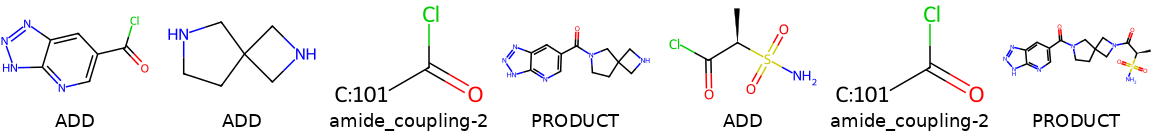

In [ ]:
import pandas as pd
props = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/zinc_properties.parquet')
props = props[props['generated_smiles'].notna()]
from helpers import create_reaction_diagram, get_reactions, parse_annotated_path, execute_path
from helpers import plot_3d


import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

def view_3d(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    
    viewer = py3Dmol.view(width=400, height=400)
    viewer.addModel(Chem.MolToMolBlock(mol), 'mol')
    viewer.setStyle({'stick': {}, 'sphere': {'radius': 0.3}})
    viewer.zoomTo()
    return viewer


row = props.sample(n=1)
print(props.iloc[7].source_properties)

create_reaction_diagram(props.iloc[7].synthesis_path)


['[highly_druglike]' '[membrane_bbb]' '[synth_easy]' '[logp_3_5]'
 '[flex_moderate]' '[flat_3d]']


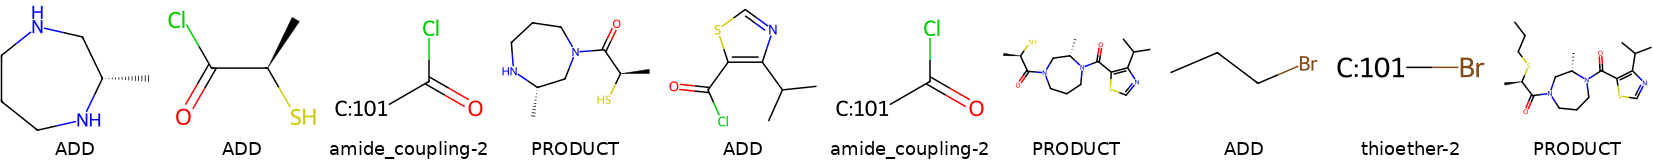

In [81]:
very3d = props[props.source_properties.str.contains('[flat_3d]', na=False, regex=False)]
row = very3d.sample(n=1).iloc[0]
print(row.source_properties)
create_reaction_diagram(row.synthesis_path)

In [82]:
view_3d(row.generated_smiles)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

['[highly_druglike]' '[membrane_bbb]' '[synth_easy]' '[logp_3_5]'
 '[flex_moderate]' '[flat_planar]']


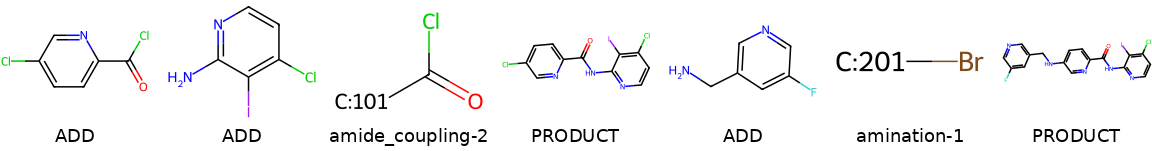

In [63]:
very3planar = props[props.source_properties.str.contains('[flat_planar]', na=False, regex=False)]
row = very3planar.sample(n=1).iloc[0]
print(row.source_properties)
create_reaction_diagram(row.synthesis_path)

In [64]:

view_3d(row.generated_smiles)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

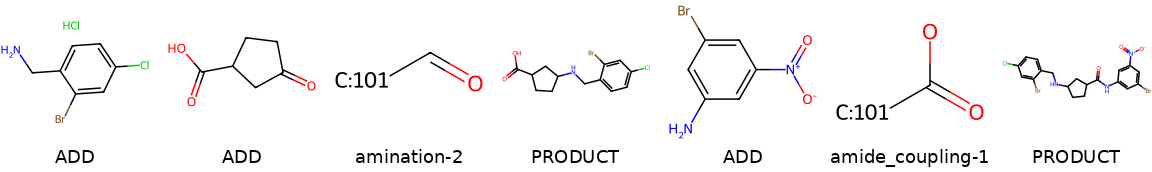

In [3]:
seno = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/seno_enamine_blocks.parquet')
seno = seno[seno['logit_mean'] > .2]
create_reaction_diagram(seno.sample(n=1).iloc[0].synthesis_path)

Target: CC[C@@H](C)[C@H](C(=O)N1CCO[C@H](C)[C@H]1C(=O)NCc1cnccc1OC)N(C)C
Path: <ADD>C[C@H]1OCCN[C@@H]1C(=O)Cl<ADD>NC[B-](F)(F)F<RXN>amide_coupling-2<ADD>CC[C@@H](C)[C@@H](Br)C(=O)O<RXN>amide_coupling-1<ADD>CNC<RXN>alkylation-1<ADD>COc1ccncc1Br<RXN>suzuki-2


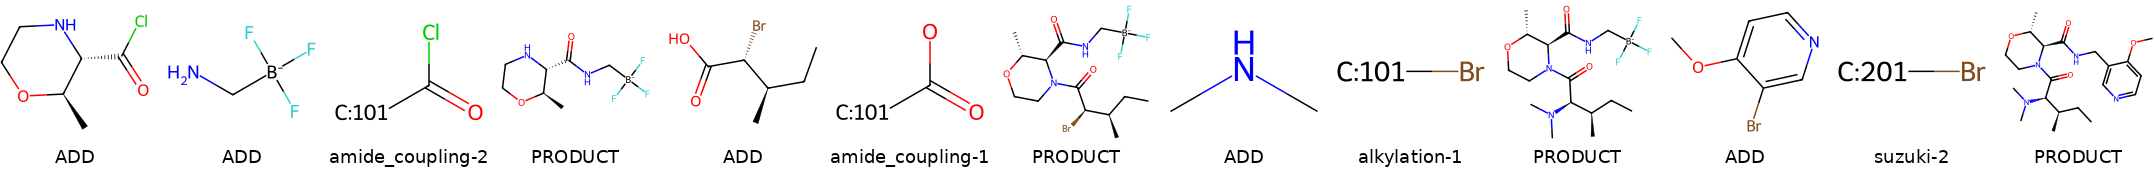

In [2]:
from helpers import sample_and_visualize

sample_and_visualize()

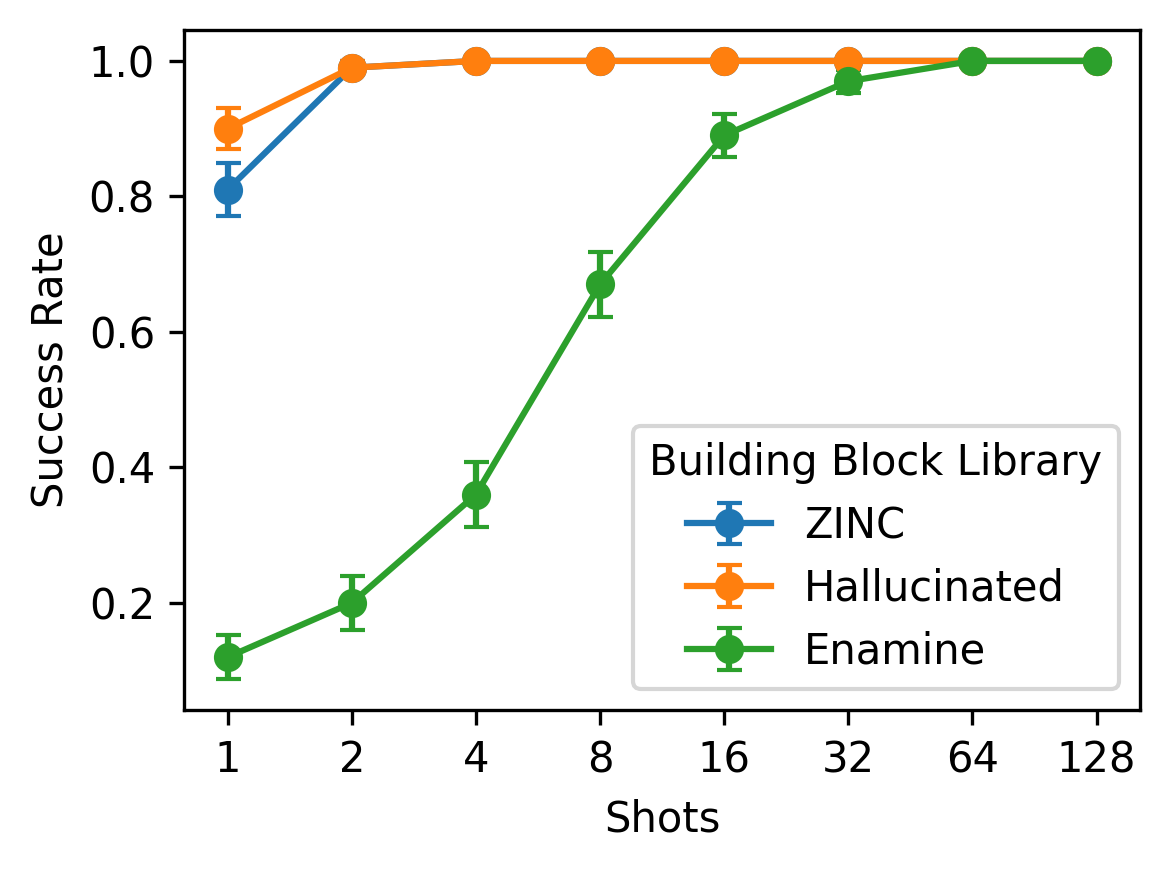

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = []
tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/zinc_properties.parquet')
tmp['building_blocks'] = 'ZINC'
df.append(tmp)

tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/hallucinated_properties.parquet')
tmp['building_blocks'] = 'Hallucinated'
df.append(tmp)

tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/enamine_properties.parquet')
tmp['building_blocks'] = 'Enamine'
df.append(tmp)

df = pd.concat(df)

# Build results
results = []
for thresh in [1, 2, 4, 8, 16, 32, 64, 128]:
    new_df = df[df['shot_number'] < thresh]
    # Get per-molecule success (boolean) - using property_score
    mol_success = (new_df.groupby(['building_blocks', 'source_smiles'])['property_score'].max() > 0.85)
    # Compute mean and std error per building block library
    stats = mol_success.groupby('building_blocks').agg(['mean', 'std', 'count'])
    for lib, row in stats.iterrows():
        se = row['std'] / np.sqrt(row['count'])
        results.append({'shots': thresh, 'perf': row['mean'], 'se': se, 'building_blocks': lib})

results_df = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
colors = {'ZINC': 'tab:blue', 'Hallucinated': 'tab:orange', 'Enamine': 'tab:green'}

for lib in ['ZINC', 'Hallucinated', 'Enamine']:
    data = results_df[results_df['building_blocks'] == lib].sort_values('shots')
    ax.errorbar(data['shots'], data['perf'], yerr=data['se'], color=colors[lib], marker='o', capsize=3, label=lib)

ax.set_xlabel('Shots')
ax.set_ylabel('Success Rate')
ax.set_xscale('log', base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend(title='Building Block Library')
plt.tight_layout()
plt.show()

In [84]:
df

,source_smiles_idx,source_smiles,source_properties,synthesis_path,generated_smiles,valid,property_score,shot_number,building_blocks
0,0,C[C@@H](C(=O)N1CC2(CN(C(=O)c3nc4c(s3)COCC4)C[C...,"[[highly_druglike], [synth_medium], [logp_neg]...",<ADD>O=C(Cl)[C@@H]1COCCO1<ADD>CC1(C)CNC[C@@H]1...,CC(C)(CS(N)(=O)=O)C(=O)NC[C@H]1CN(C(=O)[C@@H]2...,True,1.000000,0,ZINC
1,0,C[C@@H](C(=O)N1CC2(CN(C(=O)c3nc4c(s3)COCC4)C[C...,"[[highly_druglike], [synth_medium], [logp_neg]...",<ADD>O=C(Cl)c1n[nH]c(O)n1<ADD>N[C@]1(CF)CCNC1<...,O=C(N[C@]1(CF)CCN(C(=O)CCc2nc[nH]n2)C1)c1n[nH]...,True,1.000000,1,ZINC
2,0,C[C@@H](C(=O)N1CC2(CN(C(=O)c3nc4c(s3)COCC4)C[C...,"[[highly_druglike], [synth_medium], [logp_neg]...",<ADD>O=C(Cl)c1ncnc(O)c1F<ADD>O=C(O)[C@H](F)[C@...,O=C1NC[C@H](CNC(=O)[C@H](F)[C@H]2CCN(C(=O)c3nc...,True,1.000000,2,ZINC
3,0,C[C@@H](C(=O)N1CC2(CN(C(=O)c3nc4c(s3)COCC4)C[C...,"[[highly_druglike], [synth_medium], [logp_neg]...",<ADD>C[C@H](NC=O)C(=O)O<ADD>C[C@@H]1CNC[C@@H]1...,C[C@H](NC=O)C(=O)N1C[C@@H](C)[C@@H](NC(=O)[C@H...,True,1.000000,3,ZINC
4,0,C[C@@H](C(=O)N1CC2(CN(C(=O)c3nc4c(s3)COCC4)C[C...,"[[highly_druglike], [synth_medium], [logp_neg]...",<ADD>NC[C@H]1CNCCOC1<ADD>C[C@H](N)C(=O)O<RXN>a...,CCC1(C#CC(=O)N2CCOC[C@@H](CNC(=O)[C@H](C)NS(C)...,True,0.800000,4,ZINC
...,...,...,...,...,...,...,...,...,...
12795,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,"[[highly_druglike], [membrane_bbb], [synth_med...",<ADD>CC(C)(C)[C@@H]1C[C@H]1C(=O)O<ADD>C1CC2CNC...,None,False,0.000000,123,Enamine
12796,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,"[[highly_druglike], [membrane_bbb], [synth_med...",<ADD>CC1CCN(C(=O)OC(C)(C)C)CC1N<ADD>CN1C[C@H](...,None,False,0.000000,124,Enamine
12797,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,"[[highly_druglike], [membrane_bbb], [synth_med...",<ADD>O=C(O)C12CC(CO1)C2<ADD>NCC1CNCCO1<RXN>ami...,CO[C@H](C)CC(=O)N1CCOC(CNC(=O)C23CC(CO2)C3)C1,True,0.833333,125,Enamine
12798,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,"[[highly_druglike], [membrane_bbb], [synth_med...",<ADD>O=C(O)c1cnn(C(F)F)c1<ADD>COC(=O)C1CCSC12C...,None,False,0.000000,126,Enamine


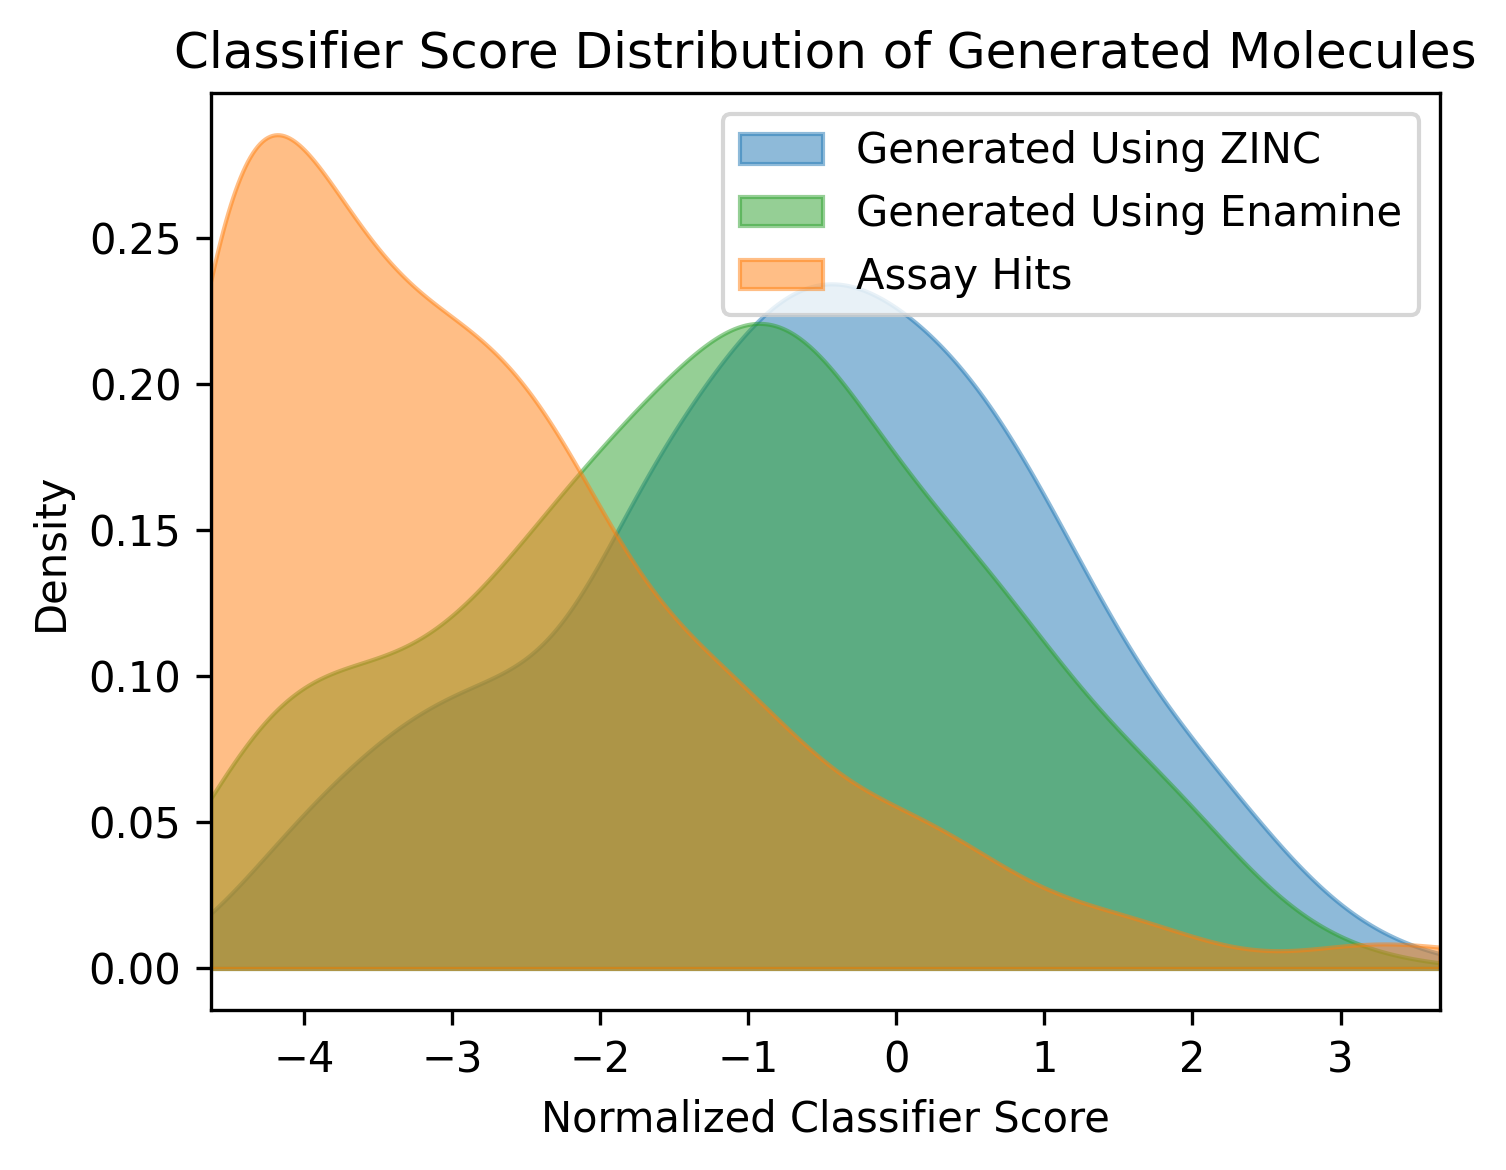

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from helpers import create_reaction_diagram, get_reactions, parse_annotated_path, execute_path


df = []
tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/seno_enamine_blocks.parquet')
tmp['building_blocks'] = 'Enamine'
df.append(tmp)
tmp = pd.read_parquet('/home/ubuntu/fragmol/robosean_evals/seno_zinc22_blocks.parquet')
tmp['building_blocks'] = 'ZINC'
df.append(tmp)
df = pd.concat(df)

real_data = pd.read_csv('s3://shvaibackups/lolmol_classifiers/seno_screen/train_data_with_predictions.csv')
hits = real_data[real_data['is_hit'] == 1]

fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# Create x range for all distributions
x = np.linspace(df['logit_mean'].min(), df['logit_mean'].max(), 500)

# ZINC
zinc_data = df[df['building_blocks'] == 'ZINC']['logit_mean'].dropna()
kde_zinc = stats.gaussian_kde(zinc_data)
ax.fill_between(x, kde_zinc(x), alpha=0.5, label='Generated Using ZINC', color='tab:blue')

# Enamine
enamine_data = df[df['building_blocks'] == 'Enamine']['logit_mean'].dropna()
kde_enamine = stats.gaussian_kde(enamine_data)
ax.fill_between(x, kde_enamine(x), alpha=0.5, label='Generated Using Enamine', color='tab:green')

# Assay Hits
hits_data = hits['logit'].dropna()
kde_hits = stats.gaussian_kde(hits_data)
ax.fill_between(x, kde_hits(x), alpha=0.5, label='Assay Hits', color='tab:orange')

ax.set_xlabel('Normalized Classifier Score')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(x.min(), x.max())
plt.title("Classifier Score Distribution of Generated Molecules")
plt.tight_layout()
plt.show()

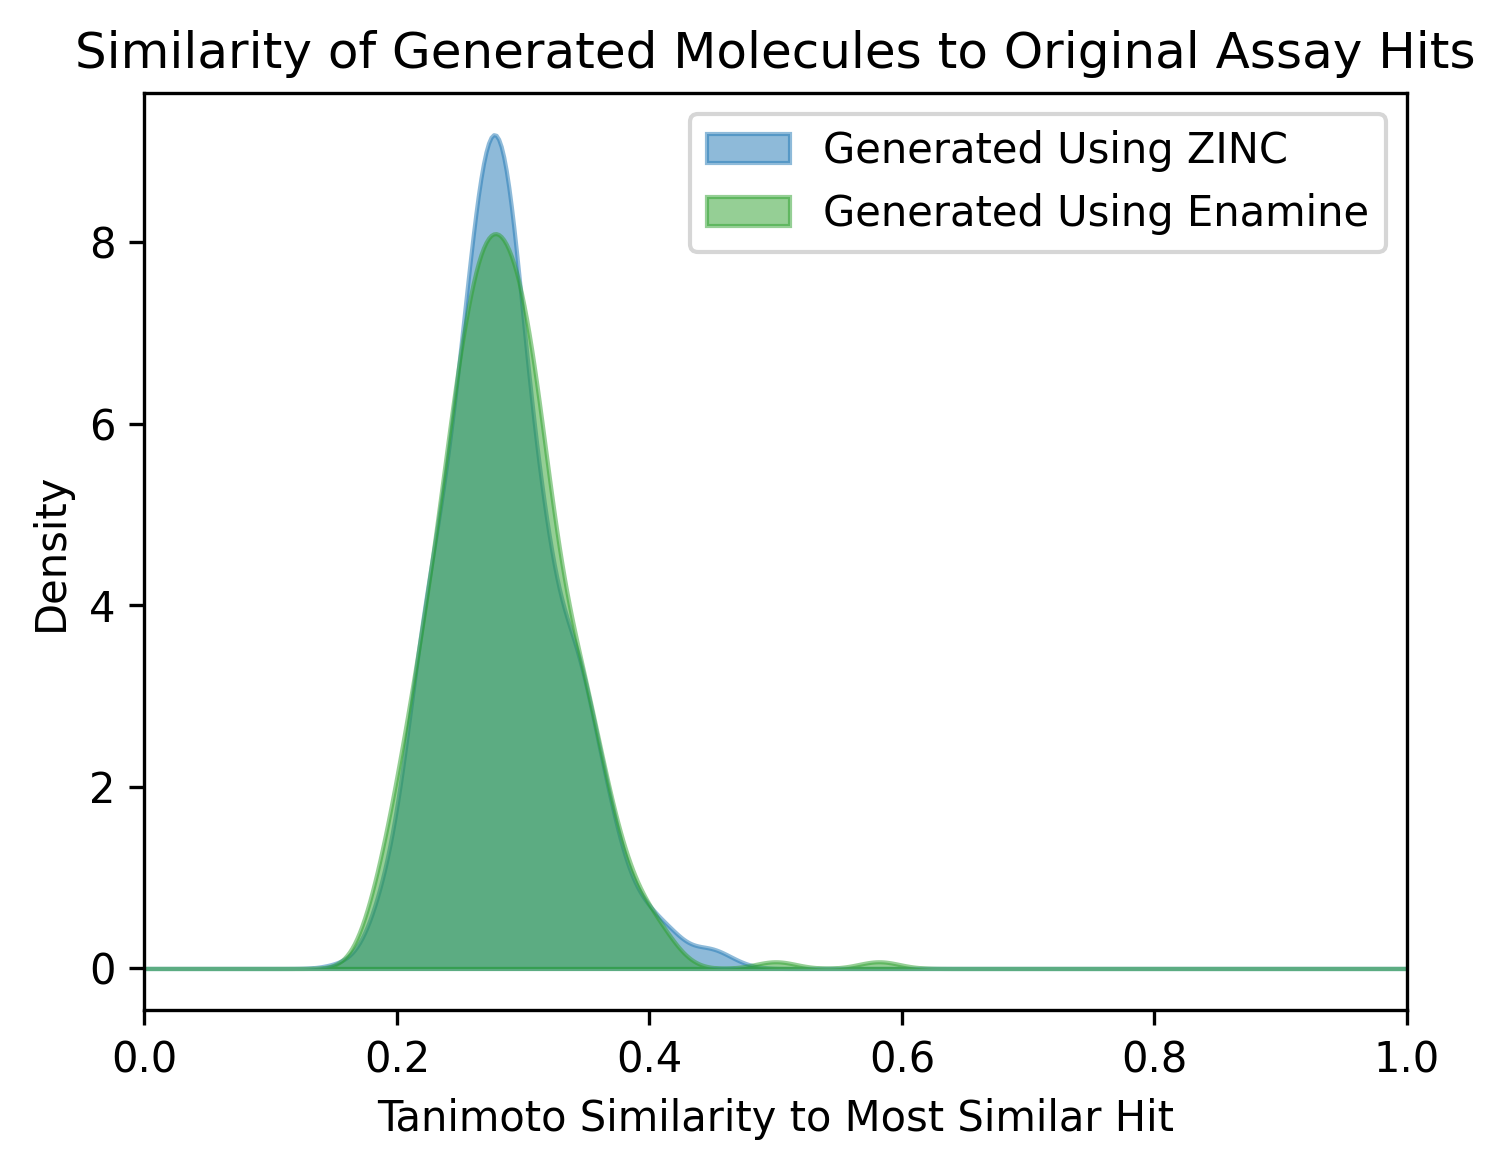

In [106]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
from scipy import stats

# Compute fingerprints for hits
hits_fps = []
for smi in hits['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        hits_fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))

# Compute max similarity to hits for each generated mol
df['max_sim_to_hit'] = None
max_sims = []
for idx, smi in enumerate(df['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        sims = DataStructs.BulkTanimotoSimilarity(fp, hits_fps)
        max_sims.append(max(sims))
    else:
        max_sims.append(np.nan)

df['max_sim_to_hit'] = max_sims

# Plot
fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
x = np.linspace(0, 1, 500)

for lib, color in [('ZINC', 'tab:blue'), ('Enamine', 'tab:green')]:
    data = df[df['building_blocks'] == lib]['max_sim_to_hit'].dropna()
    kde = stats.gaussian_kde(data)
    ax.fill_between(x, kde(x), alpha=0.5, color=color, label=f'Generated Using {lib}')

ax.set_xlabel('Tanimoto Similarity to Most Similar Hit')
ax.set_ylabel('Density')
ax.set_xlim(0, 1)
ax.legend()
plt.title("Similarity of Generated Molecules to Original Assay Hits")

plt.tight_layout()
plt.show()

In [99]:
df

,synthesis_path,smiles,logit_mean,logit_std,building_blocks
0,<ADD>O=C(Cl)c1cc(Cl)ccc1Cl<ADD>Cl.Cl.NC1CNCCC1...,Cc1c(Br)cc(C(=O)N2CCC(F)C(NC(=O)c3cc(Cl)ccc3Cl...,-0.173437,1.134413,Enamine
1,<ADD>Clc1ncc2cc(Br)ccc2n1<ADD>Cl.O=C(O)[C@H]1C...,O=C(Nc1nc(Cl)ccc1I)[C@H]1CC(F)(F)CN1c1ncc2cc(B...,-0.341406,1.723197,Enamine
2,<ADD>Cl.NCc1cccc2cc[nH]c12<ADD>CCCCC(C)CCBr<RX...,CCCCC(C)CCN(Cc1cccc2cc[nH]c12)C(=O)Cc1ccc(C)s1,-2.103259,1.377451,Enamine
3,<ADD>CC(C)(CN)NC(=O)OC(C)(C)C<ADD>CCCCCCCCCC(C...,CCCCCCCCCC(CC)C(=O)NCC(C)(C)NC(=O)OC(C)(C)C,-4.131250,0.376248,Enamine
4,<ADD>Cc1cc(C(=O)O)c(F)cc1F<ADD>Cl.Cl.NCC1CCC(N...,CCCCCCCCC(C)C(=O)NC1CCC(CNC(=O)c2cc(C)c(F)cc2F...,-1.563965,0.873431,Enamine
...,...,...,...,...,...
954,<ADD>O=C(Cl)c1cc(Br)c(F)cc1F<ADD>N[C@@H]1CCC[C...,Cc1cc(O)cc(NC(=O)[C@@H]2CCC[C@@H](NC(=O)c3cc(B...,-0.377344,1.713190,ZINC
955,<ADD>Cc1cc(C)c2nc(Cl)sc2c1<ADD>NC[C@H]1CCCNC1<...,Cc1cc(C)c2nc(N(C[C@H]3CCCNC3)C(=O)C3(C)CCC(C)C...,-0.103345,2.557545,ZINC
956,<ADD>Cc1cccc(Cl)c1C=O<ADD>O=C(Cl)CC1CNC1<RXN>a...,Cc1cccc(Cl)c1CN1CC(CC(=O)Nc2ccc(I)c3cccnc23)C1,-0.175195,0.947553,ZINC
957,<ADD>O=C(O)c1cc(F)c(F)c(Br)c1F<ADD>N[C@H]1CC[C...,Cc1c(CN[C@@H]2CC[C@H](NC(=O)c3cc(F)c(F)c(Br)c3...,0.538867,1.771859,ZINC


In [5]:
enamine_designs = df[df['building_blocks'] == 'Enamine']
enamine_designs.sort_values('logit_mean', ascending=False)

,synthesis_path,smiles,logit_mean,logit_std,building_blocks
40,<ADD>O=C(O)c1ccc2sc(Cl)nc2c1<ADD>Cl.Cl.NC1CNCC...,Cc1cc(Cl)ccc1CN1CCC(F)C(NC(=O)c2ccc3sc(Cl)nc3c...,2.995312,0.947184,Enamine
164,<ADD>Cl.O=C(O)[C@H]1CCNC[C@H]1O<ADD>Cc1cccc(N)...,Cc1cccc(NC(=O)[C@H]2CCN(Cc3cc4c(Br)cccc4s3)C[C...,2.775000,2.094230,Enamine
199,<ADD>Cl.O=C(O)C1(O)CCNC1<ADD>F[B-](F)(F)CBr.[K...,Cc1cc(NC(=O)C2(O)CCN(Cc3ccc4[nH]cc(Br)c4c3)C2)...,2.362500,0.752155,Enamine
165,<ADD>Cc1cc(F)c(C(=O)O)cc1Cl<ADD>N#Cc1cc(N)cc(F...,Cc1cc(-c2cc(C(=O)Nc3cc(F)cc(C#N)c3)c(F)cc2C)cc...,2.317188,1.563278,Enamine
34,<ADD>O=C(O)c1ccc(Br)c(Cl)c1Cl<ADD>Cl.NC1CC(=O)...,O=C(NC1CC(NCc2cc3c(F)cccc3s2)C1)c1ccc(Br)c(Cl)...,2.208594,1.054264,Enamine
...,...,...,...,...,...
301,<ADD>Cc1ccc2[nH]c(C=O)cc2c1<ADD>CC(C)(C)N<RXN>...,Cc1ccc2[nH]c(CN(C(=O)c3n[nH]c(C)c3C(=O)O)C(C)(...,-4.537500,0.201944,Enamine
100,<ADD>CNC(=O)[C@H]1C[C@H](N)C1.Cl.Cl<ADD>Cc1cc(...,CNC(=O)[C@H]1C[C@H](NCc2cc(Cl)c(C)cc2Br)C1,-4.575000,0.107529,Enamine
243,<ADD>CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[c]1ccncc...,CNC(=O)c1ccc(-c2ccncc2)cc1O,-4.587500,0.122474,Enamine
56,<ADD>Cl.Fc1cc(C2CNC2)cc(F)c1F<ADD>O=C(Cl)CCC1C...,O=C(CCC1CC1)N1CC(c2cc(F)c(F)c(F)c2)C1,-4.612500,0.183924,Enamine


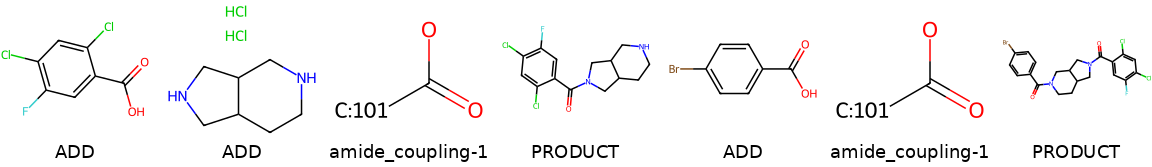

In [21]:
create_reaction_diagram(enamine_designs.iloc[14].synthesis_path)